In [5]:
import requests

test_url = "https://sotkanet.fi/rest/1.1/csv?indicator=127&years=2016&genders=total"
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"}

r = requests.get(test_url, headers=headers)
print(r.status_code)
print(r.text[:300])

200
indicator;region;year;gender;primary value;absolute value
127;967;2016;total;170770;
127;357;2016;total;9027;
127;263;2016;total;7091;
127;796;2016;total;28077;
127;841;2016;total;1159174;
127;295;2016;total;3424;
127;340;2016;total;1839;
127;498;2016;total;167599;
127;44;2016;total;19350;
127;543;2


In [6]:
# Test A: indicator 683, single year
r1 = requests.get("https://sotkanet.fi/rest/1.1/csv?indicator=683&years=2016&genders=total", headers=headers)
print("Test A:", r1.status_code)

Test A: 200


In [7]:
# Test B: indicator 127, multi-year comma-separated
r2 = requests.get("https://sotkanet.fi/rest/1.1/csv?indicator=127&years=2015,2016,2017&genders=total", headers=headers)
print("Test B:", r2.status_code)

Test B: 400


In [8]:
import pandas as pd
import requests
from io import StringIO

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"}

all_dfs = []
for year in range(2015, 2024):
    url = f"https://sotkanet.fi/rest/1.1/csv?indicator=683&years={year}&genders=total"
    r = requests.get(url, headers=headers)
    r.raise_for_status()
    df_year = pd.read_csv(StringIO(r.text), sep=";")
    all_dfs.append(df_year)

df = pd.concat(all_dfs, ignore_index=True)
print(df.shape)
df.head()

# Save the combined raw data
df.to_csv("diabetes_683_raw.csv", index=False)

(4185, 6)


In [9]:
import requests

regions_url = "https://sotkanet.fi/rest/1.1/regions"
r = requests.get(regions_url, headers=headers)
r.raise_for_status()
regions = pd.json_normalize(r.json())
print(regions.shape)
print(regions.columns.tolist())
regions.head()

(540, 8)
['id', 'code', 'category', 'memberOf', 'uri', 'title.fi', 'title.en', 'title.sv']


,id,code,category,memberOf,uri,title.fi,title.en,title.sv
0,833,1,ALUEHALLINTOVIRASTO,[],http://www.yso.fi/onto/kunnat/ahv1,Etelä-Suomen AVIn alue,Area for Southern Finland AVI,Området för Södra Finlands RFV
1,834,2,ALUEHALLINTOVIRASTO,[],http://www.yso.fi/onto/kunnat/ahv2,Lounais-Suomen AVIn alue,Area for Southwestern Finland AVI,Området för Sydvästra Finlands RFV
2,835,3,ALUEHALLINTOVIRASTO,[],http://www.yso.fi/onto/kunnat/ahv3,Itä-Suomen AVIn alue,Area for Eastern Finland AVI,Området för Östra Finlands RFV
3,836,4,ALUEHALLINTOVIRASTO,[],http://www.yso.fi/onto/kunnat/ahv4,Länsi- ja Sisä-Suomen AVIn alue,Area for Western and Inland Finland AVI,Området för Västra och Inre Finlands RFV
4,837,5,ALUEHALLINTOVIRASTO,[],http://www.yso.fi/onto/kunnat/ahv5,Pohjois-Suomen AVIn alue,Area for Northern Finland AVI,Området för Norra Finlands RFV


In [10]:
# Filter to just the 21 hyvinvointialueet
hyva_regions = regions[regions["category"] == "HYVINVOINTIALUE"][["id", "title.fi", "title.en"]]
print(hyva_regions.shape)
hyva_regions.head()

(23, 3)


,id,title.fi,title.en
79,961,Itä-Uudenmaan hyvinvointialue,East Uusimaa wellbeing services county
80,966,Keski-Uudenmaan hyvinvointialue,Central Uusimaa wellbeing services county
81,969,Länsi-Uudenmaan hyvinvointialue,West Uusimaa wellbeing services county
82,977,Vantaan ja Keravan hyvinvointialue,Vantaa and Kerava wellbeing services county
83,978,Varsinais-Suomen hyvinvointialue,Southwest Finland wellbeing services county


In [11]:
df_diabetes = pd.merge(
    df,
    hyva_regions,
    left_on="region",
    right_on="id",
    how="inner"
)
print(df_diabetes.shape)
df_diabetes.head()

(207, 9)


,indicator,region,year,gender,primary value,absolute value,id,title.fi,title.en
0,683,978,2015,total,9.6,24631,978,Varsinais-Suomen hyvinvointialue,Southwest Finland wellbeing services county
1,683,957,2015,total,9.9,7682,957,Etelä-Karjalan hyvinvointialue,South Karelia wellbeing services county
2,683,961,2015,total,9.1,4900,961,Itä-Uudenmaan hyvinvointialue,East Uusimaa wellbeing services county
3,683,972,2015,total,11.9,11483,972,Pohjois-Karjalan hyvinvointialue,North Karelia wellbeing services county
4,683,975,2015,total,9.5,11420,975,Päijät-Hämeen hyvinvointialue,Päijät-Häme wellbeing services county


In [12]:
df_diabetes.to_csv("diabetes_by_hyvinvointialue.csv", index=False)

In [13]:
import requests
import pandas as pd
import json

url = "https://pxdata.stat.fi/PxWeb/api/v1/en/StatFin/tjt/statfin_tjt_pxt_118w.px"

query = {
    "query": [
        {
            "code": "contentscode",
            "selection": {"filter": "item", "values": ["tjt-ekvikturaha_med"]}
        },
        {
            "code": "timeperiod_y",
            "selection": {"filter": "item", "values": [
                "2015","2016","2017","2018","2019","2020","2021","2022","2023","2024"
            ]}
        },
        {
            "code": "alue_23_20250101",
            "selection": {"filter": "item", "values": [
                "HVA01","HVA02","HVA03","HVA04","HVA05","HVA06","HVA07","HVA08","HVA09","HVA10",
                "HVA11","HVA12","HVA13","HVA14","HVA15","HVA16","HVA17","HVA18","HVA19","HVA20",
                "HVA21","HVA90","HVA91"
            ]}
        }
    ],
    "response": {"format": "json-stat2"}
}

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"}

r = requests.post(url, json=query, headers=headers)
print(r.status_code)
print(r.text[:500])

400
Bad Request


In [14]:
url = "https://pxdata.stat.fi/PxWeb/api/v1/en/StatFin/tjt/118w.px"

r = requests.post(url, json=query, headers=headers)
print(r.status_code)
print(r.text[:500])

200
{"version":"2.0","class":"dataset","label":"Income and income structure of household-dwelling units by Information, Year and Region","source":"Statistics Finland, income distribution statistics","updated":"2025-12-16T06:00:00Z","note":["<A HREF='https://stat.fi/en/statistics/documentation/tjt' TARGET=_blank>Documentation of statistics</A>",". missing","\r\nData in euros are given in the value of the latest statistical year.\r\nStatistical unit: household-dwelling unit. \r\nIncome concept: Dispos


In [15]:
!pip install pyjstat -q

from pyjstat import pyjstat
import pandas as pd
from io import StringIO

r = requests.post(url, json=query, headers=headers)
r.raise_for_status()

dataset = pyjstat.Dataset.read(r.text)
df_income = dataset.write('dataframe')

print(df_income.shape)
df_income.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.0/798.0 kB 12.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
(230, 4)


,Information,Year,Region,value
0,Disposable monetary income per consumption uni...,2015,HVA01 East Uusimaa wellbeing services county,30675
1,Disposable monetary income per consumption uni...,2015,HVA02 Central Uusimaa wellbeing services county,31487
2,Disposable monetary income per consumption uni...,2015,HVA03 West Uusimaa wellbeing services county,32611
3,Disposable monetary income per consumption uni...,2015,HVA04 Vantaa and Kerava wellbeing services county,30961
4,Disposable monetary income per consumption uni...,2015,HVA05 Southwest Finland wellbeing services county,27190


In [16]:
# Extract HVA code and clean region name
df_income['hva_code'] = df_income['Region'].str.extract(r'(HVA\d+)')
df_income['region_name'] = df_income['Region'].str.replace(r'HVA\d+\s*', '', regex=True)

# Rename Year to match dtype (it may be string vs int)
df_income['Year'] = df_income['Year'].astype(int)
df_diabetes['year'] = df_diabetes['year'].astype(int)

# Merge on region name + year
merged = pd.merge(
    df_diabetes,
    df_income,
    left_on=['title.en', 'year'],
    right_on=['region_name', 'Year'],
    how='inner'
)

print(merged.shape)
merged.head()

(207, 15)


,indicator,region,year,gender,primary value,absolute value,id,title.fi,title.en,Information,Year,Region,value,hva_code,region_name
0,683,978,2015,total,9.6,24631,978,Varsinais-Suomen hyvinvointialue,Southwest Finland wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA05 Southwest Finland wellbeing services county,27190,HVA05,Southwest Finland wellbeing services county
1,683,957,2015,total,9.9,7682,957,Etelä-Karjalan hyvinvointialue,South Karelia wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA11 South Karelia wellbeing services county,26541,HVA11,South Karelia wellbeing services county
2,683,961,2015,total,9.1,4900,961,Itä-Uudenmaan hyvinvointialue,East Uusimaa wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA01 East Uusimaa wellbeing services county,30675,HVA01,East Uusimaa wellbeing services county
3,683,972,2015,total,11.9,11483,972,Pohjois-Karjalan hyvinvointialue,North Karelia wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA14 North Karelia wellbeing services county,24637,HVA14,North Karelia wellbeing services county
4,683,975,2015,total,9.5,11420,975,Päijät-Hämeen hyvinvointialue,Päijät-Häme wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA09 Päijät-Häme wellbeing services county,26080,HVA09,Päijät-Häme wellbeing services county


In [17]:
merged.to_csv("diabetes_income_merged.csv", index=False)

In [18]:
url_65plus = "https://pxdata.stat.fi/PxWeb/api/v1/en/StatFin/vaerak/11ra.px"

query_65plus = {
    "query": [
        {
            "code": "alue_23_20260101",
            "selection": {"filter": "item", "values": [
                "HVA01","HVA02","HVA03","HVA04","HVA05","HVA06","HVA07","HVA08","HVA09","HVA10",
                "HVA11","HVA12","HVA13","HVA14","HVA15","HVA16","HVA17","HVA18","HVA19","HVA20",
                "HVA21","HVA90","HVA91"
            ]}
        },
        {
            "code": "contentscode",
            "selection": {"filter": "item", "values": ["vaesto_yli64_p"]}
        },
        {
            "code": "timeperiod_y",
            "selection": {"filter": "item", "values": [
                "2015","2016","2017","2018","2019","2020","2021","2022","2023"
            ]}
        }
    ],
    "response": {"format": "json-stat2"}
}

r = requests.post(url_65plus, json=query_65plus, headers=headers)
print(r.status_code)

dataset_65plus = pyjstat.Dataset.read(r.text)
df_65plus = dataset_65plus.write('dataframe')

print(df_65plus.shape)
df_65plus.head()

200
(207, 4)


,Area,Information,Year,value
0,HVA01 East Uusimaa wellbeing services county,"Share of persons aged 65 or over, %",2015,20.0
1,HVA01 East Uusimaa wellbeing services county,"Share of persons aged 65 or over, %",2016,20.5
2,HVA01 East Uusimaa wellbeing services county,"Share of persons aged 65 or over, %",2017,21.1
3,HVA01 East Uusimaa wellbeing services county,"Share of persons aged 65 or over, %",2018,21.5
4,HVA01 East Uusimaa wellbeing services county,"Share of persons aged 65 or over, %",2019,22.0


In [19]:
# Clean region name the same way as the income data
df_65plus['hva_code'] = df_65plus['Area'].str.extract(r'(HVA\d+)')
df_65plus['region_name'] = df_65plus['Area'].str.replace(r'HVA\d+\s*', '', regex=True)
df_65plus['Year'] = df_65plus['Year'].astype(int)

# Rename value column so it doesn't clash with income's 'value' column
df_65plus = df_65plus.rename(columns={'value': 'pct_65plus'})

# Merge onto your existing merged dataset
final = pd.merge(
    merged,
    df_65plus[['region_name', 'Year', 'pct_65plus']],
    left_on=['region_name', 'year'],
    right_on=['region_name', 'Year'],
    how='inner'
)

print(final.shape)
final.head()

(207, 17)


,indicator,region,year,gender,primary value,absolute value,id,title.fi,title.en,Information,Year_x,Region,value,hva_code,region_name,Year_y,pct_65plus
0,683,978,2015,total,9.6,24631,978,Varsinais-Suomen hyvinvointialue,Southwest Finland wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA05 Southwest Finland wellbeing services county,27190,HVA05,Southwest Finland wellbeing services county,2015,21.7
1,683,957,2015,total,9.9,7682,957,Etelä-Karjalan hyvinvointialue,South Karelia wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA11 South Karelia wellbeing services county,26541,HVA11,South Karelia wellbeing services county,2015,25.0
2,683,961,2015,total,9.1,4900,961,Itä-Uudenmaan hyvinvointialue,East Uusimaa wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA01 East Uusimaa wellbeing services county,30675,HVA01,East Uusimaa wellbeing services county,2015,20.0
3,683,972,2015,total,11.9,11483,972,Pohjois-Karjalan hyvinvointialue,North Karelia wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA14 North Karelia wellbeing services county,24637,HVA14,North Karelia wellbeing services county,2015,23.7
4,683,975,2015,total,9.5,11420,975,Päijät-Hämeen hyvinvointialue,Päijät-Häme wellbeing services county,Disposable monetary income per consumption uni...,2015,HVA09 Päijät-Häme wellbeing services county,26080,HVA09,Päijät-Häme wellbeing services county,2015,24.1


In [21]:
final_clean = final[[
    'region_name', 'year', 'primary_value', 'value', 'pct_65plus'
]].rename(columns={
    'primary_value': 'diabetes_rate',
    'value': 'median_income'
})

print(final_clean.shape)
final_clean.head()
final_clean.to_csv("final_merged_dataset.csv", index=False)

KeyError: "['primary_value'] not in index"

In [22]:
final_clean = final[[
    'region_name', 'year', 'primary value', 'value', 'pct_65plus'
]].rename(columns={
    'primary value': 'diabetes_rate',
    'value': 'median_income'
})

print(final_clean.shape)
final_clean.head()

(207, 5)


,region_name,year,diabetes_rate,median_income,pct_65plus
0,Southwest Finland wellbeing services county,2015,9.6,27190,21.7
1,South Karelia wellbeing services county,2015,9.9,26541,25.0
2,East Uusimaa wellbeing services county,2015,9.1,30675,20.0
3,North Karelia wellbeing services county,2015,11.9,24637,23.7
4,Päijät-Häme wellbeing services county,2015,9.5,26080,24.1


In [23]:
final_clean.to_csv("final_merged_dataset.csv", index=False)

In [24]:
final_clean = final_clean.sort_values(['region_name', 'year'])

# Lagged socioeconomic features (previous year's values)
final_clean['income_lag1'] = final_clean.groupby('region_name')['median_income'].shift(1)
final_clean['pct_65plus_lag1'] = final_clean.groupby('region_name')['pct_65plus'].shift(1)

# Year-over-year change in diabetes rate
final_clean['diabetes_change'] = final_clean.groupby('region_name')['diabetes_rate'].diff()

# Drop rows with no lag (first year per region has no prior data)
model_df = final_clean.dropna(subset=['income_lag1', 'pct_65plus_lag1', 'diabetes_change']).copy()

# Risk label: top third of diabetes_change = high risk
threshold = model_df['diabetes_change'].quantile(2/3)
model_df['risk_label'] = (model_df['diabetes_change'] >= threshold).astype(int)

print(model_df.shape)
print(model_df['risk_label'].value_counts())
model_df.head()

(184, 9)
risk_label
0    122
1     62
Name: count, dtype: int64


,region_name,year,diabetes_rate,median_income,pct_65plus,income_lag1,pct_65plus_lag1,diabetes_change,risk_label
37,Central Finland wellbeing services county,2016,11.1,26259,21.6,25954.0,21.2,0.3,0
58,Central Finland wellbeing services county,2017,11.4,26455,22.2,26259.0,21.6,0.3,1
78,Central Finland wellbeing services county,2018,11.6,26655,22.6,26455.0,22.2,0.2,0
111,Central Finland wellbeing services county,2019,11.9,26918,23.2,26655.0,22.6,0.3,1
136,Central Finland wellbeing services county,2020,12.0,26948,23.7,26918.0,23.2,0.1,0


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GroupKFold
import numpy as np

X = model_df[['income_lag1', 'pct_65plus_lag1']]
y = model_df['risk_label']
groups = model_df['region_name']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()

# Group K-Fold so the same region doesn't appear in both train and test
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(model, X_scaled, y, groups=groups, cv=gkf, scoring='accuracy')

print("CV accuracy scores:", scores)
print("Mean accuracy:", scores.mean())

# Fit on full data for interpretation
model.fit(X_scaled, y)
odds_ratios = np.exp(model.coef_[0])
for feature, odds in zip(X.columns, odds_ratios):
    print(f"{feature}: odds ratio = {odds:.3f}")

CV accuracy scores: [0.725   0.525   0.7     0.5     0.71875]
Mean accuracy: 0.63375
income_lag1: odds ratio = 0.576
pct_65plus_lag1: odds ratio = 0.787


In [26]:
r_test = requests.get("https://sotkanet.fi/rest/1.1/csv?indicator=683&years=2005&genders=total", headers=headers)
print(r_test.status_code)
print(r_test.text[:300])

200
indicator;region;year;gender;primary value;absolute value
683;181;2005;total;4.8;86
683;243;2005;total;6.3;209
683;305;2005;total;6.6;253
683;9;2005;total;5.2;268
683;838;2005;total;6.0;6093
683;88;2005;total;6.6;911
683;198;2005;total;4.6;384
683;166;2005;total;4.2;27
683;414;2005;total;6.6;904
683


In [27]:
r_test = requests.get("https://sotkanet.fi/rest/1.1/csv?indicator=683&years=2005&genders=total", headers=headers)
df_test = pd.read_csv(StringIO(r_test.text), sep=";")
print(df_test[df_test['region'].isin([978, 957, 961])])

     indicator  region  year gender  primary value  absolute value
150        683     957  2005  total            6.1            4683
382        683     978  2005  total            5.2           12231
446        683     961  2005  total            4.7            2289


In [28]:
query_test = {
    "query": [
        {"code": "contentscode", "selection": {"filter": "item", "values": ["tjt-ekvikturaha_med"]}},
        {"code": "timeperiod_y", "selection": {"filter": "item", "values": ["2005", "2010", "2015"]}},
        {"code": "alue_23_20250101", "selection": {"filter": "item", "values": ["HVA05", "HVA11", "HVA01"]}}
    ],
    "response": {"format": "json-stat2"}
}

r_test = requests.post(url, json=query_test, headers=headers)
print(r_test.status_code)
print(r_test.text[:600])

200
{"version":"2.0","class":"dataset","label":"Income and income structure of household-dwelling units by Information, Year and Region","source":"Statistics Finland, income distribution statistics","updated":"2025-12-16T06:00:00Z","note":["<A HREF='https://stat.fi/en/statistics/documentation/tjt' TARGET=_blank>Documentation of statistics</A>",". missing","\r\nData in euros are given in the value of the latest statistical year.\r\nStatistical unit: household-dwelling unit. \r\nIncome concept: Disposable monetary income (incl. sales profits), per consumption unit and household-dwelling unit, main i


In [29]:
dataset_test = pyjstat.Dataset.read(r_test.text)
df_test_income = dataset_test.write('dataframe')
print(df_test_income)

                                         Information  Year  \
0  Disposable monetary income per consumption uni...  2005   
1  Disposable monetary income per consumption uni...  2005   
2  Disposable monetary income per consumption uni...  2005   
3  Disposable monetary income per consumption uni...  2010   
4  Disposable monetary income per consumption uni...  2010   
5  Disposable monetary income per consumption uni...  2010   
6  Disposable monetary income per consumption uni...  2015   
7  Disposable monetary income per consumption uni...  2015   
8  Disposable monetary income per consumption uni...  2015   

                                              Region  value  
0       HVA01 East Uusimaa wellbeing services county  27283  
1  HVA05 Southwest Finland wellbeing services county  24746  
2      HVA11 South Karelia wellbeing services county  23674  
3       HVA01 East Uusimaa wellbeing services county  30410  
4  HVA05 Southwest Finland wellbeing services county  27304  
5      

In [30]:
all_dfs = []
for year in range(2005, 2024):
    url_d = f"https://sotkanet.fi/rest/1.1/csv?indicator=683&years={year}&genders=total"
    r = requests.get(url_d, headers=headers)
    r.raise_for_status()
    df_year = pd.read_csv(StringIO(r.text), sep=";")
    all_dfs.append(df_year)

df_diabetes_full = pd.concat(all_dfs, ignore_index=True)
df_diabetes_full = pd.merge(df_diabetes_full, hyva_regions, left_on="region", right_on="id", how="inner")
print(df_diabetes_full.shape)

(437, 9)


In [31]:
query_income_full = {
    "query": [
        {"code": "contentscode", "selection": {"filter": "item", "values": ["tjt-ekvikturaha_med"]}},
        {"code": "timeperiod_y", "selection": {"filter": "item", "values": [str(y) for y in range(2005, 2025)]}},
        {"code": "alue_23_20250101", "selection": {"filter": "item", "values": [
            "HVA01","HVA02","HVA03","HVA04","HVA05","HVA06","HVA07","HVA08","HVA09","HVA10",
            "HVA11","HVA12","HVA13","HVA14","HVA15","HVA16","HVA17","HVA18","HVA19","HVA20",
            "HVA21","HVA90","HVA91"
        ]}}
    ],
    "response": {"format": "json-stat2"}
}

r_income = requests.post(url, json=query_income_full, headers=headers)
dataset_income_full = pyjstat.Dataset.read(r_income.text)
df_income_full = dataset_income_full.write('dataframe')
print(df_income_full.shape)

(460, 4)


In [32]:
query_65_full = {
    "query": [
        {"code": "alue_23_20260101", "selection": {"filter": "item", "values": [
            "HVA01","HVA02","HVA03","HVA04","HVA05","HVA06","HVA07","HVA08","HVA09","HVA10",
            "HVA11","HVA12","HVA13","HVA14","HVA15","HVA16","HVA17","HVA18","HVA19","HVA20",
            "HVA21","HVA90","HVA91"
        ]}},
        {"code": "contentscode", "selection": {"filter": "item", "values": ["vaesto_yli64_p"]}},
        {"code": "timeperiod_y", "selection": {"filter": "item", "values": [str(y) for y in range(2005, 2024)]}}
    ],
    "response": {"format": "json-stat2"}
}

r_65 = requests.post(url_65plus, json=query_65_full, headers=headers)
dataset_65_full = pyjstat.Dataset.read(r_65.text)
df_65_full = dataset_65_full.write('dataframe')
print(df_65_full.shape)

(437, 4)


In [33]:
# Clean diabetes data (already merged with hyva_regions in the pull step)
df_diabetes_full = df_diabetes_full.rename(columns={'primary value': 'diabetes_rate'})
df_diabetes_full['year'] = df_diabetes_full['year'].astype(int)

# Clean income data
df_income_full['region_name'] = df_income_full['Region'].str.replace(r'HVA\d+\s*', '', regex=True)
df_income_full['Year'] = df_income_full['Year'].astype(int)
df_income_full = df_income_full.rename(columns={'value': 'median_income'})

# Clean 65+ data
df_65_full['region_name'] = df_65_full['Area'].str.replace(r'HVA\d+\s*', '', regex=True)
df_65_full['Year'] = df_65_full['Year'].astype(int)
df_65_full = df_65_full.rename(columns={'value': 'pct_65plus'})

# Merge all three
merged_full = pd.merge(
    df_diabetes_full[['title.en', 'year', 'diabetes_rate']],
    df_income_full[['region_name', 'Year', 'median_income']],
    left_on=['title.en', 'year'], right_on=['region_name', 'Year'],
    how='inner'
)
merged_full = pd.merge(
    merged_full,
    df_65_full[['region_name', 'Year', 'pct_65plus']],
    on=['region_name', 'Year'],
    how='inner'
)

final_clean_full = merged_full[['region_name', 'year', 'diabetes_rate', 'median_income', 'pct_65plus']]
print(final_clean_full.shape)
final_clean_full.head()

(437, 5)


,region_name,year,diabetes_rate,median_income,pct_65plus
0,Kainuu wellbeing services county,2005,6.3,22065,19.0
1,Central Finland wellbeing services county,2005,6.3,23240,16.6
2,North Karelia wellbeing services county,2005,7.0,21734,18.3
3,Lapland wellbeing services county,2005,6.0,22940,17.2
4,Päijät-Häme wellbeing services county,2005,5.6,23428,17.6


In [34]:
final_clean_full = final_clean_full.sort_values(['region_name', 'year'])

# Lagged socioeconomic features
final_clean_full['income_lag1'] = final_clean_full.groupby('region_name')['median_income'].shift(1)
final_clean_full['pct_65plus_lag1'] = final_clean_full.groupby('region_name')['pct_65plus'].shift(1)

# Year-over-year change in diabetes rate
final_clean_full['diabetes_change'] = final_clean_full.groupby('region_name')['diabetes_rate'].diff()

# Drop rows with no lag
model_df_full = final_clean_full.dropna(subset=['income_lag1', 'pct_65plus_lag1', 'diabetes_change']).copy()

# Risk label: top third of diabetes_change = high risk
threshold = model_df_full['diabetes_change'].quantile(2/3)
model_df_full['risk_label'] = (model_df_full['diabetes_change'] >= threshold).astype(int)

print(model_df_full.shape)
print(model_df_full['risk_label'].value_counts())

# Save this version
model_df_full.to_csv("model_dataset_full.csv", index=False)

(414, 9)
risk_label
0    245
1    169
Name: count, dtype: int64


In [35]:
X = model_df_full[['income_lag1', 'pct_65plus_lag1']]
y = model_df_full['risk_label']
groups = model_df_full['region_name']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(model, X_scaled, y, groups=groups, cv=gkf, scoring='accuracy')

print("CV accuracy scores:", scores)
print("Mean accuracy:", scores.mean())

model.fit(X_scaled, y)
odds_ratios = np.exp(model.coef_[0])
for feature, odds in zip(X.columns, odds_ratios):
    print(f"{feature}: odds ratio = {odds:.3f}")

CV accuracy scores: [0.62222222 0.47777778 0.64444444 0.5        0.59722222]
Mean accuracy: 0.5683333333333334
income_lag1: odds ratio = 0.659
pct_65plus_lag1: odds ratio = 0.671


In [36]:
final_clean_full = final_clean_full.sort_values(['region_name', 'year'])

# Cross-sectional risk label: top third of diabetes_rate WITHIN each year
final_clean_full['risk_label'] = final_clean_full.groupby('year')['diabetes_rate']\
    .transform(lambda x: (x >= x.quantile(2/3)).astype(int))

# No lagging needed now — using same-year socioeconomic predictors
model_df_cs = final_clean_full.dropna(subset=['median_income', 'pct_65plus']).copy()

print(model_df_cs.shape)
print(model_df_cs['risk_label'].value_counts())

(437, 9)
risk_label
0    282
1    155
Name: count, dtype: int64


In [37]:
X = model_df_cs[['median_income', 'pct_65plus']]
y = model_df_cs['risk_label']
groups = model_df_cs['region_name']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(model, X_scaled, y, groups=groups, cv=gkf, scoring='accuracy')

print("CV accuracy scores:", scores)
print("Mean accuracy:", scores.mean())

model.fit(X_scaled, y)
odds_ratios = np.exp(model.coef_[0])
for feature, odds in zip(X.columns, odds_ratios):
    print(f"{feature}: odds ratio = {odds:.3f}")

CV accuracy scores: [0.71578947 0.65263158 0.64210526 0.75       0.75      ]
Mean accuracy: 0.7021052631578948
median_income: odds ratio = 0.121
pct_65plus: odds ratio = 2.646


In [38]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Use the most recent year available
latest_year = model_df_cs['year'].max()
latest_df = model_df_cs[model_df_cs['year'] == latest_year].copy()

print(latest_year, latest_df.shape)

# Cluster on diabetes rate + income + % 65+ together
cluster_features = latest_df[['diabetes_rate', 'median_income', 'pct_65plus']]
cluster_scaled = StandardScaler().fit_transform(cluster_features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
latest_df['cluster'] = kmeans.fit_predict(cluster_scaled)

print(latest_df.groupby('cluster')[['diabetes_rate', 'median_income', 'pct_65plus']].mean())
print(latest_df.groupby('cluster')['region_name'].apply(list))

2023 (23, 9)
         diabetes_rate  median_income  pct_65plus
cluster                                          
0             6.800000   32069.000000   24.200000
1            11.933333   27075.333333   23.416667
2            13.218182   26405.272727   28.854545
3            10.220000   30910.000000   19.220000
cluster
0                                              [Åland]
1    [Central Finland wellbeing services county, Ce...
2    [Kainuu wellbeing services county, Kanta-Häme ...
3    [Central Uusimaa wellbeing services county, Ci...
Name: region_name, dtype: object


In [40]:
pd.set_option('display.max_colwidth', None)
for c in sorted(latest_df['cluster'].unique()):
    print(f"\nCluster {c}:")
    print(latest_df[latest_df['cluster'] == c]['region_name'].tolist())


Cluster 0:
['Åland']

Cluster 1:
['Central Finland wellbeing services county', 'Central Ostrobothnia wellbeing services county', 'North Ostrobothnia wellbeing services county', 'Ostrobothnia wellbeing services county', 'Pirkanmaa wellbeing services county', 'Southwest Finland wellbeing services county']

Cluster 2:
['Kainuu wellbeing services county', 'Kanta-Häme wellbeing services county', 'Kymenlaakso wellbeing services county', 'Lapland wellbeing services county', 'North Karelia wellbeing services county', 'North Savo wellbeing services county', 'Päijät-Häme wellbeing services county', 'Satakunta wellbeing services county', 'South Karelia wellbeing services county', 'South Ostrobothnia wellbeing services county', 'South Savo wellbeing services county']

Cluster 3:
['Central Uusimaa wellbeing services county', 'City of Helsinki', 'East Uusimaa wellbeing services county', 'Vantaa and Kerava wellbeing services county', 'West Uusimaa wellbeing services county']


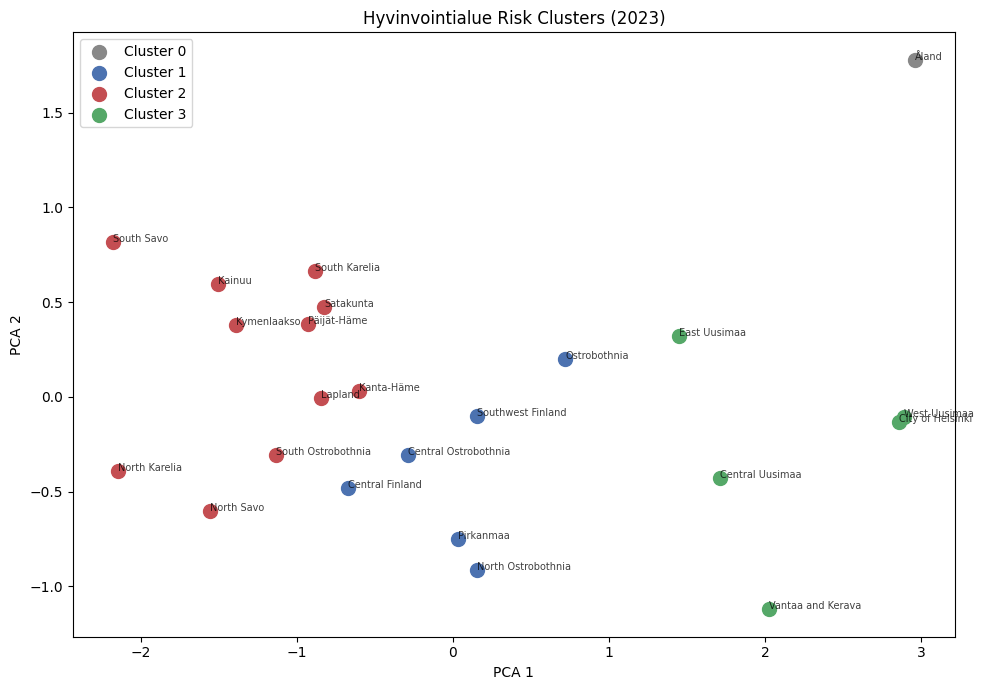

In [41]:
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(cluster_scaled)
latest_df['pca1'] = pca_coords[:, 0]
latest_df['pca2'] = pca_coords[:, 1]

plt.figure(figsize=(10, 7))
colors = ['#888888', '#4C72B0', '#C44E52', '#55A868']
for c in sorted(latest_df['cluster'].unique()):
    subset = latest_df[latest_df['cluster'] == c]
    plt.scatter(subset['pca1'], subset['pca2'], label=f'Cluster {c}', s=100, color=colors[c])

for _, row in latest_df.iterrows():
    plt.annotate(row['region_name'].replace(' wellbeing services county', ''),
                 (row['pca1'], row['pca2']), fontsize=7, alpha=0.75)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title(f'Hyvinvointialue Risk Clusters ({latest_year})')
plt.legend()
plt.tight_layout()
plt.savefig('risk_clusters.png', dpi=150)
plt.show()

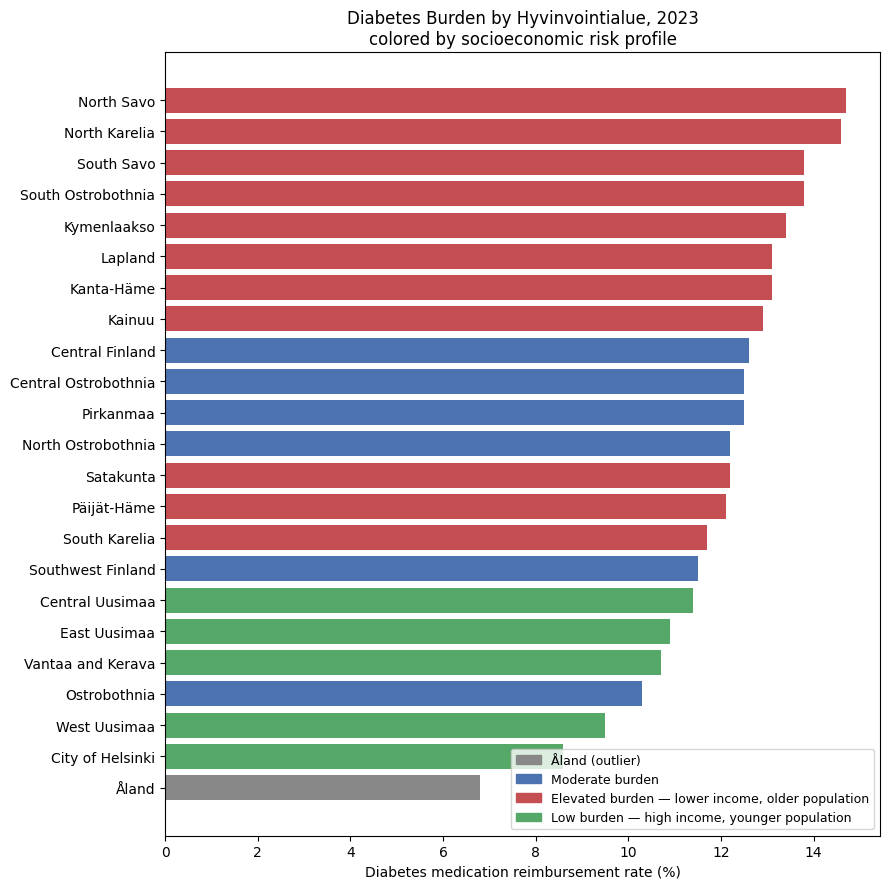

In [42]:
latest_df_sorted = latest_df.sort_values('diabetes_rate', ascending=True)

cluster_names = {
    0: 'Åland (outlier)',
    1: 'Moderate burden',
    2: 'Elevated burden — lower income, older population',
    3: 'Low burden — high income, younger population'
}
colors_map = {0: '#888888', 1: '#4C72B0', 2: '#C44E52', 3: '#55A868'}

plt.figure(figsize=(9, 9))
bar_colors = latest_df_sorted['cluster'].map(colors_map)
plt.barh(latest_df_sorted['region_name'].str.replace(' wellbeing services county', ''),
         latest_df_sorted['diabetes_rate'], color=bar_colors)

# Legend
handles = [plt.Rectangle((0,0),1,1, color=colors_map[c]) for c in cluster_names]
plt.legend(handles, cluster_names.values(), loc='lower right', fontsize=9)

plt.xlabel('Diabetes medication reimbursement rate (%)')
plt.title(f'Diabetes Burden by Hyvinvointialue, {latest_year}\ncolored by socioeconomic risk profile')
plt.tight_layout()
plt.savefig('risk_clusters_bar.png', dpi=150)
plt.show()